In [1]:
import numpy as np
import pandas as pd
from scipy.stats import zscore
import matplotlib.pyplot as plt

In [2]:
!pip install factor-analyzer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.8/42.8 kB 3.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for factor-analyzer: filename=factor_analyzer-0.5.1-py2.py3-none-any.whl size=42655 sha256=a372cd01a863c83cde1956acb84c47f07ec5def11bc19a52e34b8bd435ab723c
  Stored in directory: /root/.cache/pip/wheels/a2/af/06/f4d4ed4d9d714fda437fb1583629417319603c2266e7b233cc
Successfully built factor-analyzer


In [3]:
from factor_analyzer import FactorAnalyzer

In [4]:
my_data = pd.read_csv('example_5.csv')
my_data2 = my_data.drop('No', axis=1)
# my_data2 = pd.read_csv('prob_3-2.csv', index_col=0)
zscored_array = zscore(my_data2) # 標準化
zscored_df = pd.DataFrame(zscored_array,
                          index=my_data2.index,
                          columns=my_data2.columns)
my_data2 = zscored_df

In [5]:
fa = FactorAnalyzer(n_factors=2) # n_factors が因子数
fa.fit(my_data2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=2, rotation_kwargs={})

In [6]:
# 因子負荷行列
# (5, 2)の行列 5は5科目から来ている
fa.loadings_

array([[ 8.83840850e-01,  8.42562417e-02],
       [ 9.66336738e-01, -5.37829666e-02],
       [-7.11000907e-02,  9.69503720e-01],
       [ 1.00812936e-01,  9.34221590e-01],
       [ 8.37407093e-01, -4.03118521e-04]])

In [7]:
# 因子スコア（因子得点）
Y = fa.transform(my_data2)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


In [8]:
Y

array([[ 1.37278   ,  0.64691088],
       [-0.47536141, -1.3652506 ],
       [-0.47103322,  0.06624528],
       [ 0.88827981,  1.51804366],
       [ 1.22715184, -0.62019703],
       [-1.2985695 , -1.25600519],
       [-0.09089026, -0.5956225 ],
       [ 0.91360457,  1.65821125],
       [-0.75665067,  0.29264247],
       [-1.30931116, -0.34497822]])

In [9]:
factor1 = Y[:, 0]
factor2 = Y[:, 1]
loadings = fa.loadings_

共通因子（つまり今回は2つの因子）で説明される割合を見る．

数学の共通性が94.4%で一番高い．
一方で英語の共通性が70.1%で一番低い．

数学は理系度から一番説明されるのは直感的にも納得がいく．
英語は文系・理系どちらにとっても重要性が高いということも，分からなくはない．

In [10]:
# 共通性
# 共通因子（つまり今回は2つの因子）で説明される割合
fa.get_communalities()

array([0.78827376, 0.9366993 , 0.94499269, 0.88293323, 0.7012508 ])

独自性も見ておく．

独自性は1から共通性を引いたもので，要するに「誤差」成分でどれだけ説明されるかを示している．

In [11]:
# 独自性
# 誤差によって説明される割合
fa.get_uniquenesses()

array([0.21172624, 0.0633007 , 0.05500731, 0.11706677, 0.2987492 ])

累積寄与率を見ておく．

つまるところ，因子の説明能力である．

2つの因子で約85%なので，データの変動は十分に説明できているとわかる．

In [12]:
# 分散（因子負荷量，つまり固有値の二乗），寄与率，累積寄与率
fa.get_factor_variance()

(array([2.43145045, 1.82269933]),
 array([0.48629009, 0.36453987]),
 array([0.48629009, 0.85082996]))

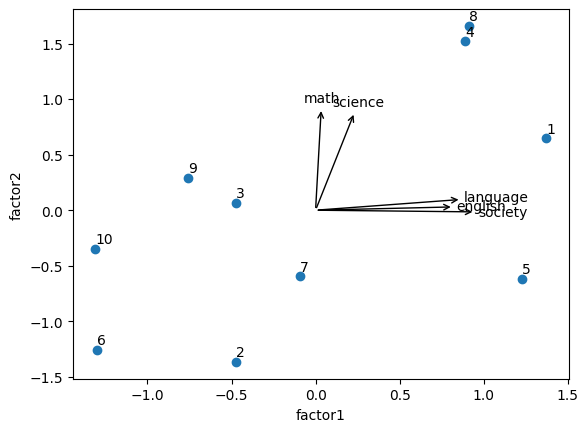

In [13]:
# バイプロット作成
# prob_3-2.csvだとラベルが文字化けするとき
# → column[i]に対応する英語ラベルを別変数で作っておけばよい
fig, ax = plt.subplots()
plt.scatter(factor1, factor2)
for i in range(5):
  ax.annotate(my_data2.columns[i], xy=(0, 0),
              xytext=(loadings[i, 0], loadings[i, 1]),
              arrowprops=dict(arrowstyle='<-'))
for i in range(len(Y)):
  ax.annotate(f"{i+1}", xy=(factor1[i], factor2[i]+0.05))

ax.set_xlabel('factor1')
ax.set_ylabel('factor2')

plt.show()

factor1は文系度，factor2は理系度ということが解釈できる（すごくないですか？）

プロットの右上ほど成績が良い．右下ほど成績が良くない．